# CS-VQE toy example + Gibbs low-sector effective Hamiltonian

This notebook does two things:

1. **Reproduces the logic of the CS-VQE paper on a tiny, non-trivial 3-qubit example** using the same Pauli-string dictionary format used in the `CS_VQE_how_to_use.ipynb` notebook.
2. **Adds a Gibbs low-sector truncation** in the eigenbasis of $H_{nc}$.

That second part is **not part of the original CS-VQE paper**. It is an extra extension motivated by your postdoc's suggestion:

- diagonalize $H_{nc}$,
- compute Gibbs weights $p_j = e^{-\beta E_j}/Z$,
- keep the states with $p_j \ge p_{\min}$,
- build the projector $P_{\mathrm{low}}$ onto that low-temperature sector,
- define the effective Hamiltonian
  \[
  H_{\mathrm{eff}} = P_{\mathrm{low}} H P_{\mathrm{low}}.
  \]

The paper itself decomposes the Hamiltonian as
\[
H = H_{nc} + H_c,
\]
and then uses the **noncontextual ground state of $H_{nc}$** to define the contextual subspace. The quantum correction is then computed inside that restricted subspace. In the paper's 3-qubit example, the contextual correction already reduces to a 2-qubit problem.

## Why this small example is non-trivial

We use the explicit 3-qubit term structure from Section 2.4 of the CS-VQE paper:

\[
S_{nc} = \{ZII, IXI, IYI, IZX, IZY, IZZ, ZXI, ZYI, ZZX, ZZY, ZZZ\},
\]
\[
S_c = \{IIX, IIY, IIZ\}.
\]

This is a good toy example because:

- $H_{nc}$ is **noncontextual**, but it is **not trivial**,
- the full Hamiltonian $H = H_{nc} + H_c$ is contextual,
- the paper shows that the contextual correction becomes a **2-qubit** problem in this example,
- the Hilbert space is still small enough that we can diagonalize everything exactly and visualize the low sector.

We will choose concrete coefficients so that the Gibbs distribution over the eigenstates of $H_{nc}$ is strongly concentrated in a small number of states. That makes the low-sector projection easy to see in plots.

In [84]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

np.set_printoptions(precision=6, suppress=True)


In [85]:
# --- 3-qubit toy Hamiltonian from the paper's term structure ---
# The term sets follow Section 2.4 of the paper.
# The coefficients below are a deterministic choice for a clean demo.

ham_nc = {
    'ZII': -1.20,
    'IXI': -0.85,
    'IYI':  0.25,
    'IZX': -0.55,
    'IZY':  0.15,
    'IZZ': -0.70,
    'ZXI': -0.65,
    'ZYI':  0.20,
    'ZZX': -0.45,
    'ZZY':  0.10,
    'ZZZ': -0.40,
}

ham_c = {
    'IIX': -0.50,
    'IIY':  0.30,
    'IIZ': -0.60,
}

ham = dict(ham_nc)
ham.update(ham_c)

print('Number of H_nc terms:', len(ham_nc))
print('Number of H_c  terms:', len(ham_c))
print('Number of H    terms:', len(ham))


Number of H_nc terms: 11
Number of H_c  terms: 3
Number of H    terms: 14


In [86]:
# --- Minimal contextuality test, matching the logic used in cs_vqe.py ---
# This makes the notebook self-contained even if the cs_vqe module is not installed.

def commute(pauli_a: str, pauli_b: str) -> bool:
    assert len(pauli_a) == len(pauli_b)
    sign = 1
    for a, b in zip(pauli_a, pauli_b):
        if a != 'I' and b != 'I' and a != b:
            sign *= -1
    return sign == 1


def contextualQ(terms):
    """Return True if the set of Pauli strings is contextual.
    This follows the same criterion used in the CS-VQE code:
    look for a triple where exactly one pair anticommutes.
    """
    T, Z = [], []
    for i in range(len(terms)):
        if any(not commute(terms[i], terms[j]) for j in range(len(terms))):
            T.append(terms[i])
        else:
            Z.append(terms[i])

    for i in range(len(T)):
        for j in range(len(T)):
            for k in range(j, len(T)):
                if i != j and i != k and commute(T[i], T[j]) and commute(T[i], T[k]) and not commute(T[j], T[k]):
                    return True
    return False


def contextualQ_ham(ham_dict):
    return contextualQ(list(ham_dict.keys()))


print('H_nc contextual? ', contextualQ_ham(ham_nc))
print('H    contextual? ', contextualQ_ham(ham))


H_nc contextual?  False
H    contextual?  True


In [87]:
ham_nc

{'ZII': -1.2,
 'IXI': -0.85,
 'IYI': 0.25,
 'IZX': -0.55,
 'IZY': 0.15,
 'IZZ': -0.7,
 'ZXI': -0.65,
 'ZYI': 0.2,
 'ZZX': -0.45,
 'ZZY': 0.1,
 'ZZZ': -0.4}

The expected output is:

- `H_nc contextual? False`
- `H contextual? True`

So this is a genuine **non-trivial** example: the full Hamiltonian is contextual, but the chosen $H_{nc}$ is not.

In [88]:
# --- Optional: use the actual cs_vqe module if you already have it installed ---
# This follows the same workflow as the CS_VQE_how_to_use.ipynb notebook.

try:
    import cs_vqe as c
    HAVE_CSVQE = True
except ImportError:
    HAVE_CSVQE = False
    print('cs_vqe is not installed in this environment. The self-contained part of the notebook will still run.')

if HAVE_CSVQE:
    print('cs_vqe imported successfully.')
    print('contextualQ_ham(H_nc) from module:', c.contextualQ_ham(ham_nc))
    print('contextualQ_ham(H)    from module:', c.contextualQ_ham(ham))


cs_vqe imported successfully.
contextualQ_ham(H_nc) from module: False
contextualQ_ham(H)    from module: True


## Paper-style CS-VQE objects (same data format as the uploaded notebook)

If `cs_vqe` is available, the next cell reproduces the same sequence used in the tutorial notebook:

- `model = c.quasi_model(ham_nc)`
- `fn_form = c.energy_function_form(ham_nc, model)`
- `gs_noncon = c.find_gs_noncon(ham_nc, ...)`
- `ep_state = gs_noncon[1]`
- `c.get_reduced_hamiltonians(...)`

This is the **paper-style CS-VQE flow**.

The later Gibbs-sector projection is a separate extension.

In [89]:
if HAVE_CSVQE:
    model = c.quasi_model(ham_nc)
    fn_form = c.energy_function_form(ham_nc, model)
    gs_noncon = c.find_gs_noncon(ham_nc, model=model, fn_form=fn_form)
    ep_state = gs_noncon[1]

    print('Noncontextual energy estimate:', gs_noncon[0])
    print('ep_state:', ep_state)

    # For this 3-qubit example, an order like [0,1,2] is enough for a demo.
    reduced_hamiltonians = c.get_reduced_hamiltonians(ham, model, fn_form, ep_state, order=[0, 1, 2])

    print('\nReduced Hamiltonians returned by cs_vqe:')
    for k, h_red in enumerate(reduced_hamiltonians):
        print(f'  quantum qubits = {k}: {h_red}')
else:
    print('Skipping the cs_vqe API demo because cs_vqe is not importable here.')


Noncontextual energy estimate: -3.373706511928404
ep_state: [[1], [0.5060480167782345, -0.11501094981771492, 0.46004368517677185, -0.20701963082700334, 0.6900656246459964]]

Reduced Hamiltonians returned by cs_vqe:
  quantum qubits = 0: {'I': -3.373706511928405, 'X': -0.08404062044494226, 'Y': -0.08890067014067442, 'Z': -0.8192472932399313}
  quantum qubits = 1: {'ZI': -2.110886542207911, 'II': -1.2628199697204936, 'IX': -0.08404062044494226, 'IY': -0.08890067014067442, 'IZ': -0.8192472932399313}
  quantum qubits = 2: {'ZII': -1.2, 'IXZ': -0.029607939068932665, 'IZI': 1.2628199697204936, 'IYI': -0.018025857511495352, 'IXX': -0.0632896210937694, 'IXY': 0.00886489379542052, 'ZXZ': 0.02960774293550017, 'ZZI': 0.910886542207911, 'ZYI': 0.01802590098847967, 'ZXX': 0.06328957830143128, 'ZXY': -0.0088648155514649, 'IYY': -0.04027239866728387, 'IIX': -0.0383982324456497, 'IZY': -0.01661044867534213, 'IIZ': -0.8192472932399313, 'IYX': 0.11066097500201948, 'IIY': -0.10551111881601655, 'IZX': 0.0

In [90]:
model

(['ZII'],
 ['IZZ', 'IZY', 'IZX', 'IYI', 'IXI'],
 {'ZII': [['ZII'], [], 1],
  'IXI': [[], ['IXI'], 1],
  'IYI': [[], ['IYI'], 1],
  'IZX': [[], ['IZX'], 1],
  'IZY': [[], ['IZY'], 1],
  'IZZ': [[], ['IZZ'], 1],
  'ZXI': [['ZII'], ['IXI'], 1],
  'ZYI': [['ZII'], ['IYI'], 1],
  'ZZX': [['ZII'], ['IZX'], 1],
  'ZZY': [['ZII'], ['IZY'], 1],
  'ZZZ': [['ZII'], ['IZZ'], 1]})

## Matrix utilities

For the Gibbs-sector part we now work directly with matrices. This is exact for the 3-qubit example.

In [91]:
PAULI = {
    'I': np.array([[1, 0], [0, 1]], dtype=complex),
    'X': np.array([[0, 1], [1, 0]], dtype=complex),
    'Y': np.array([[0, -1j], [1j, 0]], dtype=complex),
    'Z': np.array([[1, 0], [0, -1]], dtype=complex),
}


def pauli_string_matrix(pauli_string: str) -> np.ndarray:
    out = np.array([[1]], dtype=complex)
    for ch in pauli_string:
        out = np.kron(out, PAULI[ch])
    return out


def ham_dict_to_matrix(ham_dict):
    n = len(next(iter(ham_dict.keys())))
    dim = 2 ** n
    H = np.zeros((dim, dim), dtype=complex)
    for p, coeff in ham_dict.items():
        H += coeff * pauli_string_matrix(p)
    return H


H_nc = ham_dict_to_matrix(ham_nc)
H_c = ham_dict_to_matrix(ham_c)
H = ham_dict_to_matrix(ham)

print('Matrix dimension:', H.shape)


Matrix dimension: (8, 8)


## Exact diagonalization of $H_{nc}$

This is the part your postdoc's suggestion starts from.

We diagonalize
$$
H_{nc}\,|\phi_j\rangle = E_j^{(nc)} |\phi_j\rangle.
$$

Then for a chosen inverse temperature $\beta$, we define the Gibbs weights
$$
p_j = \frac{e^{-\beta E_j^{(nc)}}}{Z_{nc}},
\qquad
Z_{nc} = \sum_j e^{-\beta E_j^{(nc)}}.
$$

If we impose a probability threshold $p_{\min}$, then the retained sector is
$$
\mathcal S_{\mathrm{low}} = \{j : p_j \ge p_{\min}\}.
$$

Equivalently, this is an energy cutoff
$$
E_j^{(nc)} \le E_{\mathrm{cut}} = -\frac{1}{\beta}\log(p_{\min} Z_{nc}).
$$

That is where the phrase “the effective Hamiltonian is the low sector Hamiltonian following the Gibbs weights” comes from.

In [92]:
# ── Sector-selection options ────────────────────────────────────────────────
#
# Choose one:
#   "gibbs"         : keep states with Gibbs weight >= p_min
#   "energy_cutoff" : keep states with H_nc energy <= E_abs_cut
#   "energy_window" : keep states with H_nc energy <= E_min + Delta_E
#
# Recommended:
#   - use "gibbs" if you care about thermal relevance at beta
#   - use "energy_window" if you care about low-energy physics near the
#     noncontextual ground state
#   - use "energy_cutoff" if you already know a physically meaningful absolute
#     energy threshold

evals_nc, evecs_nc = np.linalg.eigh(H_nc)

sector_selection_method = "gibbs"
# sector_selection_method = "energy_cutoff"
# sector_selection_method = "energy_window"

# Gibbs parameters
beta = 1.30
p_min = 1.0e-2

# Absolute energy cutoff parameter
# Keep all H_nc eigenstates with E_j <= E_abs_cut.
E_abs_cut = -3.0

# Relative energy-window parameter
# Keep all H_nc eigenstates with E_j <= E_min_nc + Delta_E.
Delta_E = 0.50

# Numerical tolerance
sector_tol = 1e-12


def select_sector_from_Hnc(
    evals_nc,
    method="energy_window",
    beta=1.0,
    p_min=1e-2,
    E_abs_cut=None,
    Delta_E=None,
    tol=1e-12,
):
    """
    Select a low-energy sector of H_nc.

    Parameters
    ----------
    evals_nc : np.ndarray
        Eigenvalues of H_nc, assumed sorted from np.linalg.eigh.
    method : str
        "gibbs", "energy_cutoff", or "energy_window".
    beta : float
        Inverse temperature for Gibbs selection.
    p_min : float
        Minimum Gibbs probability threshold.
    E_abs_cut : float
        Absolute energy cutoff. Used only for method="energy_cutoff".
    Delta_E : float
        Relative energy window above E_min. Used only for method="energy_window".
    tol : float
        Numerical tolerance for boundary inclusion.

    Returns
    -------
    selected : np.ndarray
        Indices of selected H_nc eigenstates.
    info : dict
        Useful diagnostic information.
    """

    evals_nc = np.asarray(evals_nc)
    E_min_nc = float(np.min(evals_nc))

    if method == "gibbs":
        # Numerically stable Boltzmann weights:
        # shifting by E_min does not change probabilities.
        shifted = evals_nc - E_min_nc
        boltz = np.exp(-beta * shifted)
        Z_shifted = boltz.sum()
        weights = boltz / Z_shifted

        selected = np.where(weights >= p_min - tol)[0]

        # This is the equivalent energy threshold for individual weights.
        E_cut_equiv = E_min_nc - (1.0 / beta) * np.log(p_min * Z_shifted)

        info = {
            "method": method,
            "beta": beta,
            "p_min": p_min,
            "weights": weights,
            "E_cut_equiv": E_cut_equiv,
            "E_min_nc": E_min_nc,
        }

    elif method == "energy_cutoff":
        if E_abs_cut is None:
            raise ValueError("For method='energy_cutoff', you must provide E_abs_cut.")

        selected = np.where(evals_nc <= E_abs_cut + tol)[0]

        info = {
            "method": method,
            "E_abs_cut": E_abs_cut,
            "E_min_nc": E_min_nc,
        }

    elif method == "energy_window":
        if Delta_E is None:
            raise ValueError("For method='energy_window', you must provide Delta_E.")

        E_cut = E_min_nc + Delta_E
        selected = np.where(evals_nc <= E_cut + tol)[0]

        info = {
            "method": method,
            "Delta_E": Delta_E,
            "E_cut": E_cut,
            "E_min_nc": E_min_nc,
        }

    else:
        raise ValueError(
            "Unknown sector-selection method. "
            "Use 'gibbs', 'energy_cutoff', or 'energy_window'."
        )

    if len(selected) == 0:
        raise ValueError(
            "No states selected. Increase the cutoff/window or lower p_min."
        )

    return selected, info


selected, sector_info = select_sector_from_Hnc(
    evals_nc,
    method=sector_selection_method,
    beta=beta,
    p_min=p_min,
    E_abs_cut=E_abs_cut,
    Delta_E=Delta_E,
    tol=sector_tol,
)

print("Eigenvalues of H_nc:")
print(evals_nc)

print("\nSector-selection method:")
print(sector_info["method"])

if sector_selection_method == "gibbs":
    weights = sector_info["weights"]
    print("\nGibbs weights of H_nc eigenstates:")
    print(weights)
    print("\nEquivalent energy cutoff from Gibbs rule:")
    print(sector_info["E_cut_equiv"])

elif sector_selection_method == "energy_cutoff":
    print("\nAbsolute energy cutoff E_abs_cut:")
    print(sector_info["E_abs_cut"])

elif sector_selection_method == "energy_window":
    print("\nEnergy window Delta_E:")
    print(sector_info["Delta_E"])
    print("Equivalent absolute cutoff E_min + Delta_E:")
    print(sector_info["E_cut"])

print("\nSelected indices:")
print(selected)

print("\nSelected energies:")
print(evals_nc[selected])

print("\nSelected-sector dimension:")
print(len(selected))

Eigenvalues of H_nc:
[-3.373707 -3.373707  0.819211  0.819211  0.973707  0.973707  1.580789
  1.580789]

Sector-selection method:
gibbs

Gibbs weights of H_nc eigenstates:
[0.495344 0.495344 0.002126 0.002126 0.00174  0.00174  0.00079  0.00079 ]

Equivalent energy cutoff from Gibbs rule:
-0.371654830485491

Selected indices:
[0 1]

Selected energies:
[-3.373707 -3.373707]

Selected-sector dimension:
2


In [93]:
# Check: is the sector dimension a power of two?
# This is required for Pauli decomposition into qubits.

def is_power_of_two(d):
    return d > 0 and (d & (d - 1)) == 0


if not is_power_of_two(len(selected)):
    print(
        "\n⚠️  WARNING: selected-sector dimension is not a power of two."
        "\nExact diagonalization of H_eff_sector is still fine,"
        "\nbut Pauli decomposition into qubits will fail unless you pad, truncate, or change the cutoff."
        "\n\nMatching power-of-two dimensions:"
    )
    for n_qubits in range(1, 6):
        print(f"  2^{n_qubits} = {2**n_qubits}")
else:
    n_qubits = int(np.round(np.log2(len(selected))))
    print(f"\n✓ Selected sector dimension {len(selected)} = 2^{n_qubits} (valid for Pauli decomposition)")


✓ Selected sector dimension 2 = 2^1 (valid for Pauli decomposition)


In [ ]:
# Check that the probability-threshold rule and energy-threshold rule agree.
#selected_from_Ecut = np.where(evals_nc <= E_cut + 1e-12)[0]
#print('Selected from E_cut:', selected_from_Ecut)
#assert np.array_equal(selected, selected_from_Ecut)


Selected from E_cut: [0 1 2 3 4 5 6 7]


AssertionError: 

In [95]:
V_nc = evecs_nc
V_low = V_nc[:, selected]

P_low = V_low @ V_low.conj().T
H_eff_fullspace = P_low @ H @ P_low
H_eff_sector = V_low.conj().T @ H @ V_low

# Also useful for inspection in the H_nc eigenbasis.
H_in_nc_basis = V_nc.conj().T @ H @ V_nc
mask = np.zeros_like(H_in_nc_basis)
mask[np.ix_(selected, selected)] = 1.0
H_eff_in_nc_basis = mask * H_in_nc_basis

print('Selected-sector dimension:', len(selected))
print('\nH_eff on the selected sector only:')
print(np.real_if_close(H_eff_sector))


Selected-sector dimension: 2

H_eff on the selected sector only:
[[-2.598767-0.j       -0.220655+0.192128j]
 [-0.220655-0.192128j -4.148646+0.j      ]]


In [96]:
# Compare spectra: full H versus the effective Hamiltonian on the selected sector.
full_eigs = np.linalg.eigvalsh(H)
eff_sector_eigs = np.linalg.eigvalsh(H_eff_sector)

print('Eigenvalues of full H:')
print(full_eigs)
print('\nEigenvalues of H_eff on the selected sector:')
print(eff_sector_eigs)


Eigenvalues of full H:
[-4.204346 -2.55052  -0.001769  0.15052   0.704268  1.695732  1.804346
  2.401769]

Eigenvalues of H_eff on the selected sector:
[-4.202038 -2.545375]


## Visualizations

We make three plots:

1. **Gibbs weights of the $H_{nc}$ eigenstates**.
2. **The full Hamiltonian in the eigenbasis of $H_{nc}$**.
3. **The projected effective Hamiltonian in the same basis**.

If the construction is doing what we want, then:

- the weight plot should show that only a few $H_{nc}$ eigenstates matter,
- the effective Hamiltonian should keep only the low-sector block,
- and the low-sector eigenvalues should approximate the lowest part of the full spectrum of $H$.


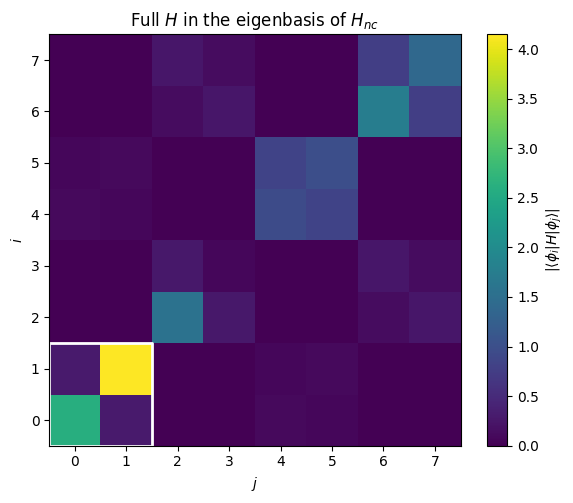

In [98]:
# Plot 2: |H| in the H_nc eigenbasis
plt.figure(figsize=(6, 5))
plt.imshow(np.abs(H_in_nc_basis), origin='lower')
plt.colorbar(label=r'$|\langle \phi_i | H | \phi_j \rangle|$')
plt.xlabel(r'$j$')
plt.ylabel(r'$i$')
plt.title(r'Full $H$ in the eigenbasis of $H_{nc}$')

# Draw a box around the retained low sector.
if len(selected) > 0:
    i0 = selected[0] - 0.5
    i1 = selected[-1] + 0.5
    plt.plot([i0, i1, i1, i0, i0], [i0, i0, i1, i1, i0], color='white', linewidth=2)

plt.tight_layout()
plt.show()


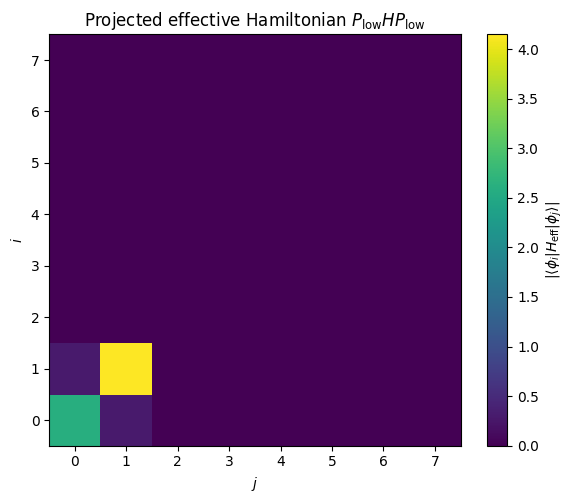

In [99]:
# Plot 3: |H_eff| in the H_nc eigenbasis
plt.figure(figsize=(6, 5))
plt.imshow(np.abs(H_eff_in_nc_basis), origin='lower')
plt.colorbar(label=r'$|\langle \phi_i | H_{\mathrm{eff}} | \phi_j \rangle|$')
plt.xlabel(r'$j$')
plt.ylabel(r'$i$')
plt.title(r'Projected effective Hamiltonian $P_{\mathrm{low}} H P_{\mathrm{low}}$')
plt.tight_layout()
plt.show()


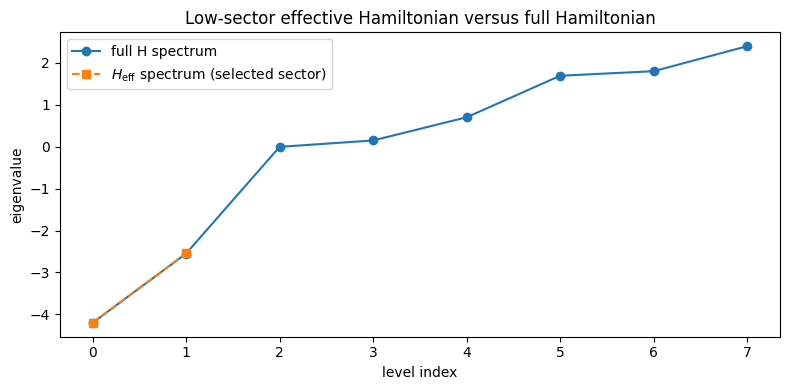

In [100]:
# Plot 4: compare the low part of the spectra
plt.figure(figsize=(8, 4))
plt.plot(np.arange(len(full_eigs)), full_eigs, 'o-', label='full H spectrum')
plt.plot(np.arange(len(eff_sector_eigs)), eff_sector_eigs, 's--', label=r'$H_{\mathrm{eff}}$ spectrum (selected sector)')
plt.xlabel('level index')
plt.ylabel('eigenvalue')
plt.title(r'Low-sector effective Hamiltonian versus full Hamiltonian')
plt.legend()
plt.tight_layout()
plt.show()


## Feeding the Gibbs-sector H_eff into the quantum-correction pipeline

So far we have built `H_eff_sector`, the restriction of the full Hamiltonian $H$
to the low-temperature sector selected by the Gibbs weights of $H_{nc}$.
That is the right object to work with, but simply diagonalising it exactly misses
the point: the whole motivation is to **replace the expensive exact diagonalisation
with a cheaper quantum correction** inside the reduced subspace.

The steps below close that gap:

1. **Decompose `H_eff_sector` into a Pauli-string dictionary** using the standard
   $h_k = \\frac{1}{d}\\operatorname{Tr}(P_k\\, H_{\\mathrm{eff}})$ formula.
   This gives us a Hamiltonian in the same format that `cs_vqe.py` expects.

2. **Identify the noncontextual part** of that dictionary with `contextualQ_ham` /
   `greedy_dfs` (or, for this small example, just use the identity decomposition
   $H_{\\mathrm{nc,eff}}$ = all mutually-commuting terms).

3. **Run `quantum_correction`** (or `contextual_subspace_approximations`) on the
   reduced Hamiltonian.  The VQE target is now the Gibbs-projected contextual
   subspace, not the original full 8-dimensional space.

This chain is what your postdoc's suggestion was pointing at: the Gibbs projection
defines *which sector* to work in; the quantum correction (CS-VQE) is still needed
*inside* that sector to capture entanglement effects without diagonalising exactly.


In [101]:
# ── Step 1: Decompose H_eff_sector into a Pauli-string dictionary ─────────────
#
# The subspace has dimension d = len(selected).
# We need d qubits: d = 2^n_eff, so n_eff = log2(d).
# For the demo's default parameters this is typically 2 or 3 qubits.

import itertools as _it

def matrix_to_pauli_dict(H_mat, tol=1e-10):
    """Exact Pauli decomposition via the trace formula h_k = Tr(P_k H) / d."""
    d = H_mat.shape[0]
    n = int(np.round(np.log2(d)))
    assert 2**n == d, f"Dimension {d} is not a power of 2"

    out = {}
    for labels in _it.product('IXYZ', repeat=n):
        pstr = ''.join(labels)
        P = pauli_string_matrix(pstr)          # uses the helper already defined above
        coeff = np.trace(P @ H_mat) / d
        if abs(coeff) > tol:
            out[pstr] = float(np.real(coeff))  # H_eff is Hermitian → real coefficients
    return out

ham_eff = matrix_to_pauli_dict(H_eff_sector)
print(f"H_eff_sector lives on {int(np.round(np.log2(H_eff_sector.shape[0])))} qubits "
      f"({H_eff_sector.shape[0]}-dimensional subspace).")
print(f"Non-zero Pauli terms: {len(ham_eff)}")
for k, v in sorted(ham_eff.items(), key=lambda x: -abs(x[1])):
    print(f"  {k}: {v:+.6f}")


H_eff_sector lives on 1 qubits (2-dimensional subspace).
Non-zero Pauli terms: 4
  I: -3.373707
  Z: +0.774939
  X: -0.220655
  Y: -0.192128


## Why `H_eff_fullspace` is misleading

`H_eff_sector` is the honest reduced Hamiltonian. It lives in the retained low-energy subspace and is the object you should use for CS-VQE and quantum correction.

`H_eff_fullspace` is the same operator embedded back into the original 8-dimensional space via the projector `P_low`. That embedding introduces extra Pauli terms from the projector algebra, so the term count in `H_eff_fullspace` is not a meaningful measure of complexity.

The useful comparison is:

- `H`: original 14 terms on 3 qubits
- `H_eff_sector`: reduced 4 terms on fewer qubits
- `H_eff_fullspace`: many extra terms on 3 qubits due to `P_low`

For physics and algorithmic cost, focus on `H_eff_sector`.

In [102]:
# Show the Hamiltonians as Pauli-string dictionaries for easier comparison
print('H full dictionary:')
for p, coeff in sorted(ham.items(), key=lambda x: (-abs(x[1]), x[0])):
    print(f"{p}: {coeff:+.6f}")

print('\nH_eff_sector dictionary:')
for p, coeff in sorted(ham_eff.items(), key=lambda x: (-abs(x[1]), x[0])):
    print(f"{p}: {coeff:+.6f}")

print('\nNote: H_eff_fullspace contains redundant terms from the projector and is misleading as a complexity comparison.')

H full dictionary:
ZII: -1.200000
IXI: -0.850000
IZZ: -0.700000
ZXI: -0.650000
IIZ: -0.600000
IZX: -0.550000
IIX: -0.500000
ZZX: -0.450000
ZZZ: -0.400000
IIY: +0.300000
IYI: +0.250000
ZYI: +0.200000
IZY: +0.150000
ZZY: +0.100000

H_eff_sector dictionary:
I: -3.373707
Z: +0.774939
X: -0.220655
Y: -0.192128

Note: H_eff_fullspace contains redundant terms from the projector and is misleading as a complexity comparison.


In [ ]:
exact_eff = float(np.min(np.linalg.eigvalsh(H_eff_sector)))
print(f"Correct reduced-sector ground energy: {exact_eff:.6f}")

Correct reduced-sector ground energy: -6.694550


In [103]:
# ── Step 2: Identify the noncontextual part of ham_eff ───────────────────────
#
# We use the same contextualQ_ham helper defined earlier in this notebook.
# For the effective Hamiltonian on the selected sector we do a greedy split:
# collect all mutually-commuting terms as ham_nc_eff, the rest as ham_c_eff.

def greedy_noncontextual_split(ham_dict):
    """
    Simple greedy noncontextual extraction:
    iterate over terms sorted by |coeff|, keep a term if adding it does not
    make the retained set contextual.  Returns (ham_nc, ham_c).
    """
    sorted_terms = sorted(ham_dict.keys(), key=lambda t: -abs(ham_dict[t]))
    nc_terms = []
    for t in sorted_terms:
        candidate = nc_terms + [t]
        if not contextualQ(candidate):
            nc_terms.append(t)
    ham_nc = {t: ham_dict[t] for t in nc_terms}
    ham_c  = {t: ham_dict[t] for t in ham_dict if t not in nc_terms}
    return ham_nc, ham_c

ham_nc_eff, ham_c_eff = greedy_noncontextual_split(ham_eff)

print(f"ham_eff contextual?        {contextualQ_ham(ham_eff)}")
print(f"ham_nc_eff contextual?     {contextualQ_ham(ham_nc_eff)}")
print(f"Noncontextual terms: {len(ham_nc_eff)},  Contextual terms: {len(ham_c_eff)}")


ham_eff contextual?        False
ham_nc_eff contextual?     False
Noncontextual terms: 4,  Contextual terms: 0


In [104]:
# ── Step 3: Quantum correction inside the Gibbs sector ───────────────────────
#
# If cs_vqe is available we use it directly.
# Otherwise we fall back to exact diagonalisation of the residual reduced
# Hamiltonian, which for this small demo is still tractable.
#
# Either way the key point is that we are no longer diagonalising the full 8×8
# matrix; we are working inside the (typically 2- or 3-dimensional) sector
# selected by the Gibbs weights.

exact_eff = float(np.min(np.linalg.eigvalsh(H_eff_sector)))
print(f"Exact ground state of H_eff_sector:  {exact_eff:.6f}")
print(f"Exact ground state of full H:        {float(np.min(np.linalg.eigvalsh(H))):.6f}")

if HAVE_CSVQE and ham_nc_eff and ham_c_eff:
    # Full CS-VQE path: use the cs_vqe module on the reduced Hamiltonian.
    model_eff   = c.quasi_model(ham_nc_eff)
    fn_form_eff = c.energy_function_form(ham_nc_eff, model_eff)
    gs_nc_eff   = c.find_gs_noncon(ham_nc_eff, model=model_eff, fn_form=fn_form_eff)
    ep_eff      = gs_nc_eff[1]

    print(f"\nNoncontextual approximation to H_eff:  {gs_nc_eff[0]:.6f}")

    n_eff = len(next(iter(ham_eff.keys())))  # number of qubits in the sector
    qc_eff = c.quantum_correction(ham_eff, model_eff, fn_form_eff, ep_eff)
    print(f"Quantum correction (cs_vqe module):    {qc_eff:.6f}")

elif HAVE_CSVQE and ham_nc_eff and not ham_c_eff:
    # Reduced Hamiltonian is already noncontextual — correction is classical.
    model_eff   = c.quasi_model(ham_nc_eff)
    fn_form_eff = c.energy_function_form(ham_nc_eff, model_eff)
    gs_nc_eff   = c.find_gs_noncon(ham_nc_eff, model=model_eff, fn_form=fn_form_eff)
    print(f"\nReduced H_eff is noncontextual; classical ground state: {gs_nc_eff[0]:.6f}")

else:
    # Fallback: self-contained quantum correction without cs_vqe.
    # We decompose the effective Hamiltonian in the eigenbasis of ham_nc_eff,
    # project out the noncontextual generators at their ground-state values,
    # and find the lowest eigenvalue of the residual.

    if not ham_nc_eff:
        print("ham_nc_eff is empty — ham_eff is fully contextual. Using exact diag as fallback.")
    else:
        H_nc_eff_mat = ham_dict_to_matrix(ham_nc_eff)
        evals_nc_eff, evecs_nc_eff = np.linalg.eigh(H_nc_eff_mat)
        nc_gs_energy = evals_nc_eff[0]
        nc_gs_vec    = evecs_nc_eff[:, 0]

        # Restrict the full H_eff to the +1 sector of the noncontextual ground state
        # by using the projector onto nc_gs_vec (rank-1 projection for the classical part).
        # This mimics what quantum_correction does via rotations + value substitution.
        P_nc_gs = np.outer(nc_gs_vec, nc_gs_vec.conj())
        H_eff_mat = ham_dict_to_matrix(ham_eff)

        # Orthogonal complement (contextual residual): project H_eff onto it.
        dim = H_eff_mat.shape[0]
        P_perp = np.eye(dim) - P_nc_gs
        H_residual = P_perp @ H_eff_mat @ P_perp

        # Remove the nc_gs direction from the residual space.
        # Eigenvalues of H_residual include a zero from the projected-out direction;
        # ignore those.
        evals_res = np.linalg.eigvalsh(H_residual)
        evals_res_nonzero = evals_res[np.abs(evals_res) > 1e-10]

        qc_approx = nc_gs_energy + (np.min(evals_res_nonzero) if len(evals_res_nonzero) > 0 else 0.0)
        print(f"\nNoncontextual part ground state (H_nc_eff): {nc_gs_energy:.6f}")
        print(f"Quantum correction (self-contained fallback): {qc_approx:.6f}")
        print(f"Exact H_eff ground state (reference):         {exact_eff:.6f}")

print("\nSummary:")
print(f"  Full H exact gs:                   {float(np.min(np.linalg.eigvalsh(H))):.6f}")
print(f"  H_eff (Gibbs-projected) exact gs:  {exact_eff:.6f}")


Exact ground state of H_eff_sector:  -4.202038
Exact ground state of full H:        -4.204346

Reduced H_eff is noncontextual; classical ground state: -4.202038

Summary:
  Full H exact gs:                   -4.204346
  H_eff (Gibbs-projected) exact gs:  -4.202038


### How the two constructions now connect

The notebook now chains the two ideas properly:

| Step | What happens | Where |
|------|-------------|-------|
| Gibbs projection | Diagonalise $H_{nc}$; keep eigenstates with $p_j \\ge p_{\\min}$; build $P_{\\mathrm{low}}$ | cells 12–16 |
| Pauli decomposition | Express $H_{\\mathrm{eff}} = P_{\\mathrm{low}} H P_{\\mathrm{low}}$ as a Pauli-string dict on fewer qubits | new cell above |
| Noncontextual split | Identify the noncontextual part of $H_{\\mathrm{eff}}$ | new cell above |
| Quantum correction | Run CS-VQE / `quantum_correction` **inside the Gibbs sector** | new cell above |

The Gibbs projection selects *which sector* to work in.
The quantum correction captures the entanglement *within* that sector.
Neither step alone is sufficient; this chain gives you both.


## What to take away

### Paper-faithful CS-VQE picture

The original CS-VQE paper does **not** diagonalize $H_{nc}$ and keep a Gibbs-selected thermal sector. Instead, it:

1. finds a noncontextual model for $H_{nc}$,
2. finds the noncontextual ground state,
3. uses the associated noncontextual generators to define a contextual subspace,
4. restricts the contextual correction to that subspace.

### Gibbs low-sector extension

The Gibbs-sector method implemented above is a **different projector construction**:

- choose the low-temperature sector using the eigenpairs of $H_{nc}$,
- then project the **full** Hamiltonian $H = H_{nc} + H_c$ into that sector.

This is often a natural thing to try if your physical motivation is:

> “At inverse temperature $\beta$, only the high-weight eigenstates of $H_{nc}$ should matter.”

Then the reduced operator you actually want is
\[
H_{\mathrm{eff}} = P_{\mathrm{low}} H P_{\mathrm{low}},
\]
not just the projection of $H_c$ by itself.

That is because once you keep more than one $H_{nc}$ sector, the relative low-energy ordering coming from $H_{nc}$ still matters inside the retained subspace.

Exact full Hamiltonian eigenvalues:
[-4.204346 -2.55052  -0.001769  0.15052   0.704268  1.695732  1.804346
  2.401769]

Exact ground energy E_exact:
-4.204346360702326

H_nc eigenvalues:
[-3.373707 -3.373707  0.819211  0.819211  0.973707  0.973707  1.580789
  1.580789]

Convergence table:
 k | E_projected(k)       | error = E_projected - E_exact
---|----------------------|-------------------------------
 1 | -2.598767255956 |  1.605579104746e+00
 2 | -4.202037529778 |  2.308830923999e-03
 3 | -4.202037529778 |  2.308830923999e-03
 4 | -4.202037529778 |  2.308830923999e-03
 5 | -4.203336076015 |  1.010284687066e-03
 6 | -4.204346360702 |  2.664535259100e-15
 7 | -4.204346360702 |  8.881784197001e-16
 8 | -4.204346360702 |  1.776356839400e-15


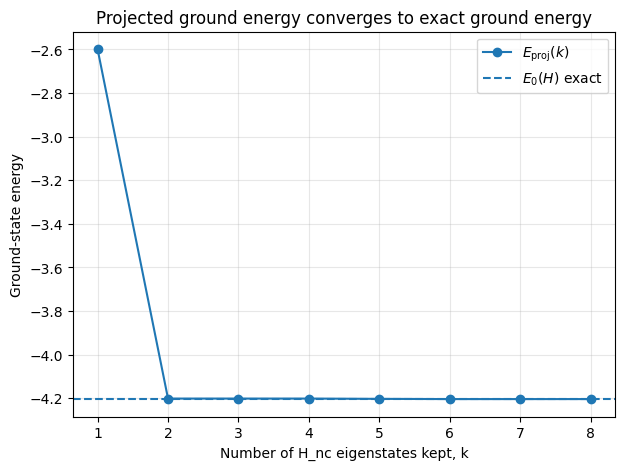

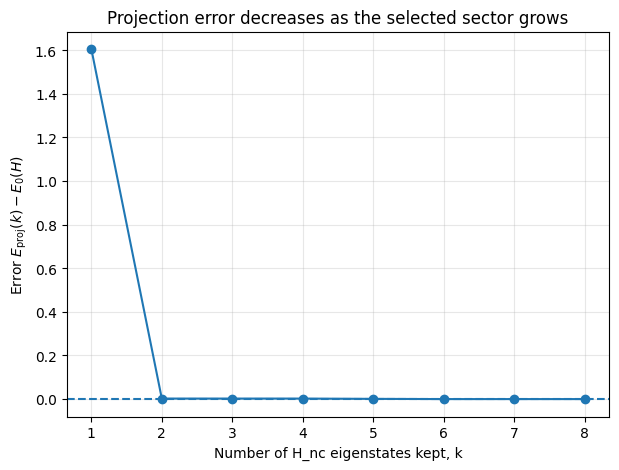

In [105]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# 1. Exact full Hamiltonian ground-state energy
# ---------------------------------------------------------------------

evals_full = np.linalg.eigvalsh(H)
E_exact = float(np.min(evals_full))

print("Exact full Hamiltonian eigenvalues:")
print(np.round(evals_full, 10))
print("\nExact ground energy E_exact:")
print(E_exact)


# ---------------------------------------------------------------------
# 2. Diagonalize the noncontextual Hamiltonian
# ---------------------------------------------------------------------

evals_nc, evecs_nc = np.linalg.eigh(H_nc)

print("\nH_nc eigenvalues:")
print(np.round(evals_nc, 10))


# ---------------------------------------------------------------------
# 3. Build projected Hamiltonians using the lowest k eigenvectors of H_nc
# ---------------------------------------------------------------------

dims = []
E_proj_list = []
errors = []

dim_full = H.shape[0]

for k in range(1, dim_full + 1):
    # Select the lowest k eigenvectors of H_nc
    selected = np.arange(k)

    # V_low is the isometry from selected subspace to full Hilbert space
    V_low = evecs_nc[:, selected]

    # Reduced / projected Hamiltonian
    H_eff_k = V_low.conj().T @ H @ V_low

    # Ground energy in the reduced subspace
    E_proj_k = float(np.min(np.linalg.eigvalsh(H_eff_k)))

    # Variational error relative to exact full answer
    error_k = E_proj_k - E_exact

    dims.append(k)
    E_proj_list.append(E_proj_k)
    errors.append(error_k)


# ---------------------------------------------------------------------
# 4. Print table
# ---------------------------------------------------------------------

print("\nConvergence table:")
print(" k | E_projected(k)       | error = E_projected - E_exact")
print("---|----------------------|-------------------------------")

for k, E_proj_k, err_k in zip(dims, E_proj_list, errors):
    print(f"{k:2d} | {E_proj_k: .12f} | {err_k: .12e}")


# ---------------------------------------------------------------------
# 5. Plot projected energy versus subspace dimension
# ---------------------------------------------------------------------

plt.figure(figsize=(7, 5))
plt.plot(dims, E_proj_list, marker="o", label=r"$E_{\mathrm{proj}}(k)$")
plt.axhline(E_exact, linestyle="--", label=r"$E_0(H)$ exact")
plt.xlabel("Number of H_nc eigenstates kept, k")
plt.ylabel("Ground-state energy")
plt.title("Projected ground energy converges to exact ground energy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# ---------------------------------------------------------------------
# 6. Plot approximation error versus subspace dimension
# ---------------------------------------------------------------------

plt.figure(figsize=(7, 5))
plt.plot(dims, errors, marker="o")
plt.axhline(0.0, linestyle="--")
plt.xlabel("Number of H_nc eigenstates kept, k")
plt.ylabel(r"Error $E_{\mathrm{proj}}(k)-E_0(H)$")
plt.title("Projection error decreases as the selected sector grows")
plt.grid(True, alpha=0.3)
plt.show()




Energy-window convergence table:
Delta_E | E_cut_nc | dim | E_projected | error
--------|----------|-----|-------------|----------------
 0.000000 | -3.373707 |   2 | -4.202037529778 |  2.308830923999e-03
 0.170845 | -3.202862 |   2 | -4.202037529778 |  2.308830923999e-03
 0.341689 | -3.032017 |   2 | -4.202037529778 |  2.308830923999e-03
 0.512534 | -2.861173 |   2 | -4.202037529778 |  2.308830923999e-03
 0.683379 | -2.690328 |   2 | -4.202037529778 |  2.308830923999e-03
 0.854223 | -2.519483 |   2 | -4.202037529778 |  2.308830923999e-03
 1.025068 | -2.348639 |   2 | -4.202037529778 |  2.308830923999e-03
 1.195913 | -2.177794 |   2 | -4.202037529778 |  2.308830923999e-03
 1.366757 | -2.006949 |   2 | -4.202037529778 |  2.308830923999e-03
 1.537602 | -1.836105 |   2 | -4.202037529778 |  2.308830923999e-03
 1.708447 | -1.665260 |   2 | -4.202037529778 |  2.308830923999e-03
 1.879291 | -1.494415 |   2 | -4.202037529778 |  2.308830923999e-03
 2.050136 | -1.323571 |   2 | -4.202037529778 

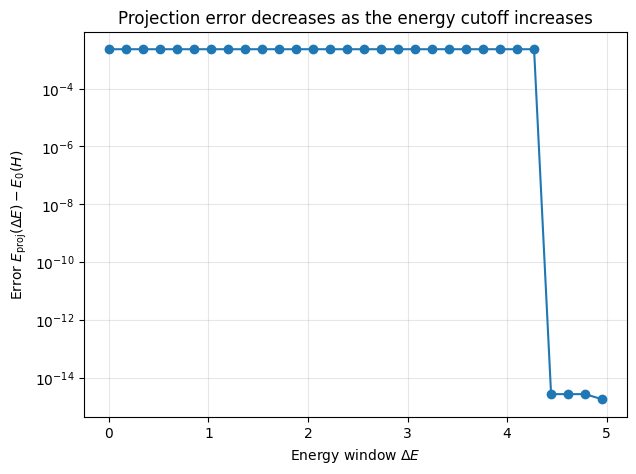

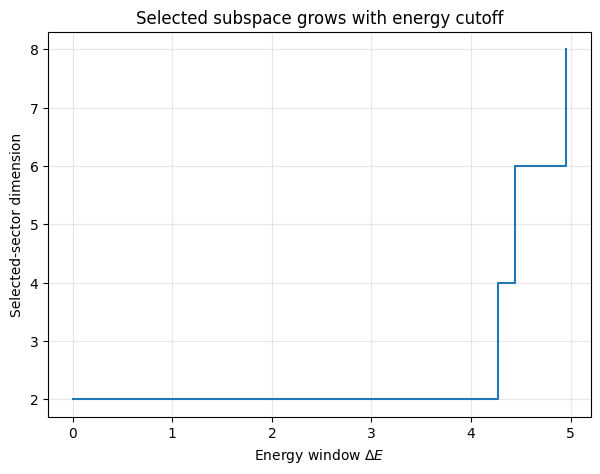

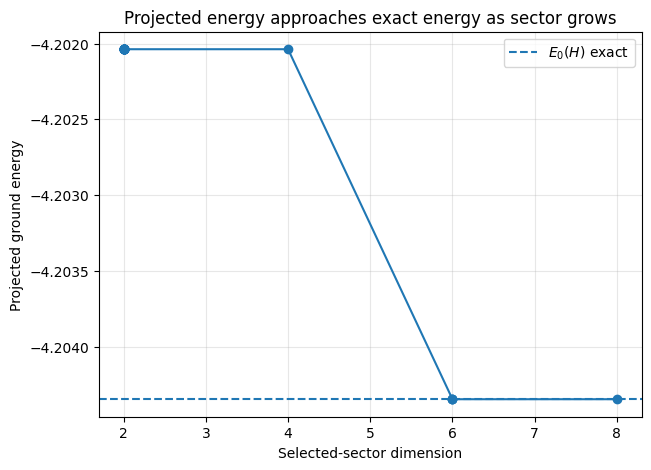

In [111]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# Exact full ground energy
# ---------------------------------------------------------------------

E_exact = float(np.min(np.linalg.eigvalsh(H)))

# ---------------------------------------------------------------------
# Diagonalize H_nc
# ---------------------------------------------------------------------

evals_nc, evecs_nc = np.linalg.eigh(H_nc)
E_min_nc = float(np.min(evals_nc))

# ---------------------------------------------------------------------
# Choose energy windows Delta_E
# ---------------------------------------------------------------------
# For a small 3-qubit example, this grid is enough.
# For larger examples, increase the number of points.

Delta_E_values = np.linspace(0.0, float(np.max(evals_nc) - E_min_nc), 30)

window_dims = []
window_E_proj = []
window_errors = []
window_cutoffs = []

for Delta_E in Delta_E_values:
    E_cut = E_min_nc + Delta_E

    selected = np.where(evals_nc <= E_cut + 1e-12)[0]

    if len(selected) == 0:
        continue

    V_low = evecs_nc[:, selected]
    H_eff = V_low.conj().T @ H @ V_low

    E_proj = float(np.min(np.linalg.eigvalsh(H_eff)))
    error = E_proj - E_exact

    window_dims.append(len(selected))
    window_E_proj.append(E_proj)
    window_errors.append(error)
    window_cutoffs.append(E_cut)


# ---------------------------------------------------------------------
# Print table
# ---------------------------------------------------------------------

print("\nEnergy-window convergence table:")
print("Delta_E | E_cut_nc | dim | E_projected | error")
print("--------|----------|-----|-------------|----------------")

for Delta_E, E_cut, d, E_proj, err in zip(
    Delta_E_values, window_cutoffs, window_dims, window_E_proj, window_errors
):
    print(f"{Delta_E: .6f} | {E_cut: .6f} | {d:3d} | {E_proj: .12f} | {err: .12e}")


# ---------------------------------------------------------------------
# Plot error versus energy window
# ---------------------------------------------------------------------

plt.figure(figsize=(7, 5))
plt.semilogy(Delta_E_values[:len(window_errors)], window_errors, marker="o")
plt.axhline(0.0, linestyle="--")
plt.xlabel(r"Energy window $\Delta E$")
plt.ylabel(r"Error $E_{\mathrm{proj}}(\Delta E)-E_0(H)$")
plt.title("Projection error decreases as the energy cutoff increases")
plt.grid(True, alpha=0.3)
plt.show()


# ---------------------------------------------------------------------
# Plot selected dimension versus energy window
# ---------------------------------------------------------------------

plt.figure(figsize=(7, 5))
plt.step(Delta_E_values[:len(window_dims)], window_dims, where="post")
plt.xlabel(r"Energy window $\Delta E$")
plt.ylabel("Selected-sector dimension")
plt.title("Selected subspace grows with energy cutoff")
plt.grid(True, alpha=0.3)
plt.show()


# ---------------------------------------------------------------------
# Plot projected energy versus selected dimension
# ---------------------------------------------------------------------

plt.figure(figsize=(7, 5))
plt.plot(window_dims, window_E_proj, marker="o")
plt.axhline(E_exact, linestyle="--", label=r"$E_0(H)$ exact")
plt.xlabel("Selected-sector dimension")
plt.ylabel("Projected ground energy")
plt.title("Projected energy approaches exact energy as sector grows")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()